In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

class RectangularHODLR:
    def __init__(self, x_rows, x_cols, kernel_fn, p=8, max_level=4, leaf_size=64):
        self.x_rows = x_rows
        self.x_cols = x_cols
        self.kernel_fn = kernel_fn
        self.p = p
        self.max_level = max_level
        self.leaf_size = leaf_size
        
        self.blocks = []
        # Precompute interpolation bases for clusters to save memory/time
        self.row_interp = {}
        self.col_interp = {}
        
        self._build(0, len(x_rows), 0, len(x_cols), level=0)

    def _get_interp_matrix(self, x_block, p):
        """Builds the Chebyshev interpolation matrix for a spatial block."""
        if len(x_block) == 0: return None
        a, b = x_block.min(), x_block.max()
        if a == b: b = a + 1e-12 # Prevent division by zero
        
        # Scale nodes to [-1, 1]
        x_scaled = (2 * x_block - (a + b)) / (b - a)
        
        # Chebyshev nodes and polynomials
        k = np.arange(p)
        nodes = np.cos((2 * k + 1) * np.pi / (2 * p))
        
        # Vandermonde-like matrices
        def cheb_poly(pts, degree):
            T = np.zeros((len(pts), degree))
            T[:, 0] = 1.0
            if degree > 1: T[:, 1] = pts
            for n in range(2, degree):
                T[:, n] = 2 * pts * T[:, n-1] - T[:, n-2]
            return T

        T_pts = cheb_poly(x_scaled, p)
        T_nodes = cheb_poly(nodes, p)
        
        # Weights for barycentric/orthogonal projection
        gamma = np.ones(p)
        gamma[0] = 0.5
        W = (2/p) * gamma
        
        return T_pts @ (W[:, None] * T_nodes.T)

    def _build(self, r0, r1, c0, c1, level):
        # Determine if this block is "Far-Field" (Off-Diagonal)
        # For PINN, rows and columns are usually aligned spatially
        is_far = (r1 <= c0) or (c1 <= r0)
        
        # Base Case: Low-Rank Approximation
        if is_far and level > 0:
            U = self._get_interp_matrix(self.x_rows[r0:r1], self.p)
            V = self._get_interp_matrix(self.x_cols[c0:c1], self.p)
            
            # Sample the kernel at Chebyshev nodes for the S (Skeleton) matrix
            k = np.arange(self.p)
            t = np.cos((2 * k + 1) * np.pi / (2 * self.p))
            
            # Map nodes back to original scale
            ar, br = self.x_rows[r0:r1].min(), self.x_rows[r0:r1].max()
            ac, bc = self.x_cols[c0:c1].min(), self.x_cols[c0:c1].max()
            nodes_r = 0.5 * (br - ar) * t + 0.5 * (br + ar)
            nodes_c = 0.5 * (bc - ac) * t + 0.5 * (bc + ac)
            
            S = self.kernel_fn(nodes_r, nodes_c)
            self.blocks.append(('lowrank', (r0, r1), (c0, c1), U, V, S))
            
        # Base Case: Dense Leaf
        elif level >= self.max_level or (r1 - r0) <= self.leaf_size:
            mat = self.kernel_fn(self.x_rows[r0:r1], self.x_cols[c0:c1])
            self.blocks.append(('dense', (r0, r1), (c0, c1), mat))
            
        # Recursion
        else:
            rmid, cmid = (r0 + r1) // 2, (c0 + c1) // 2
            self._build(r0, rmid, c0, cmid, level + 1) # Top-Left
            self._build(r0, rmid, cmid, c1, level + 1) # Top-Right
            self._build(rmid, r1, c0, cmid, level + 1) # Bottom-Left
            self._build(rmid, r1, cmid, c1, level + 1) # Bottom-Right

    def matvec(self, v):
        y = np.zeros(len(self.x_rows))
        for kind, r_range, c_range, *data in self.blocks:
            r0, r1 = r_range
            c0, c1 = c_range
            if kind == 'dense':
                y[r0:r1] += data[0] @ v[c0:c1]
            else:
                U, V, S = data
                # Optimized chain: U * (S * (V^T * v))
                y[r0:r1] += U @ (S @ (V.T @ v[c0:c1]))
        return y

Computing exact dense MatVec...
p= 2 | Error: 2.90e-03 | Time: 0.0069s
p= 4 | Error: 2.60e-03 | Time: 0.0083s
p= 6 | Error: 2.34e-03 | Time: 0.0092s
p= 8 | Error: 2.17e-03 | Time: 0.0112s
p=12 | Error: 1.90e-03 | Time: 0.0143s
p=16 | Error: 1.58e-03 | Time: 0.0160s
p=20 | Error: 1.29e-03 | Time: 0.0189s
p=32 | Error: 7.94e-04 | Time: 0.0261s


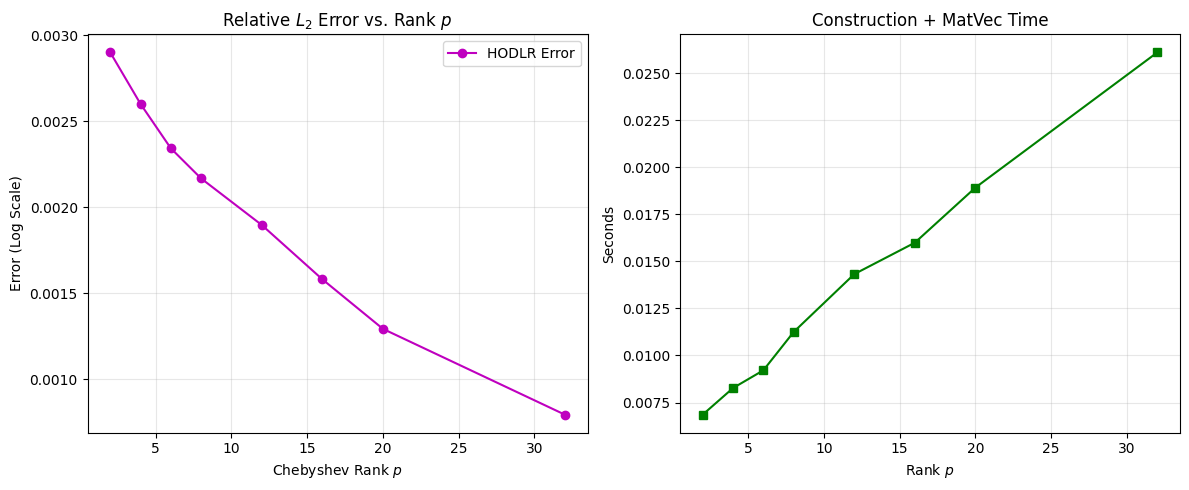

In [4]:
# --- Define the Kernel ---
def poisson_kernel(x_i, x_j):
    # Vectorized kernel evaluation
    XI, XJ = np.meshgrid(x_i, x_j, indexing='ij')
    dist = np.abs(XI - XJ)
    # Handle singularity for diagonal (self-interaction)
    K = np.where(dist < 1e-12, 100.0, 1.0 / (dist + 1e-15))
    return K

# --- Experiment Parameters ---
N_cols = 2000
N_rows = 2002 # Simulating the N+2 PINN structure
x_c = np.linspace(-1, 1, N_cols)
x_r = np.linspace(-1, 1, N_rows)
v_test = np.random.randn(N_cols)

# 1. Compute Exact Reference
print("Computing exact dense MatVec...")
A_dense = poisson_kernel(x_r, x_c)
y_exact = A_dense @ v_test
norm_exact = np.linalg.norm(y_exact)

# 2. Sweep over Rank p
ranks = [2, 4, 6, 8, 12, 16, 20, 32]
errors = []
times = []

for p in ranks:
    t0 = time.perf_counter()
    H = RectangularHODLR(x_r, x_c, poisson_kernel, p=p, max_level=5)
    y_hodlr = H.matvec(v_test)
    t1 = time.perf_counter()
    
    err = np.linalg.norm(y_exact - y_hodlr) / norm_exact
    errors.append(err)
    times.append(t1 - t0)
    print(f"p={p:2d} | Error: {err:.2e} | Time: {t1-t0:.4f}s")

# --- 3. Plotting ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ranks, errors, 'o-m', label='HODLR Error')
plt.title('Relative $L_2$ Error vs. Rank $p$')
plt.xlabel('Chebyshev Rank $p$')
plt.ylabel('Error (Log Scale)')
plt.legend()
plt.grid(True, which='both', alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(ranks, times, 's-g')
plt.title('Construction + MatVec Time')
plt.xlabel('Rank $p$')
plt.ylabel('Seconds')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()